<a href="https://colab.research.google.com/github/ignacastiguti/Repositorio/blob/main/%5B00%5D%20-%20Workshops/Workshop_ML_PartTime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workshop Final — Machine Learning Integrado




## Contexto y objetivo

Este workshop plantea un **caso de negocio en retail**: una cadena de tiendas quiere entender mejor a sus clientes y optimizar sus decisiones comerciales. Para ello se pondrá en práctica todo el ciclo de Machine Learning.

**Dataset propuesto (opcional):** [Sample - Superstore (Kaggle)](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)  

[Dataset en GitHub (no requiere autenticación)](https://raw.githubusercontent.com/dtoralg/INESDI_Data-Science_ML_IA/main/%5B00%5D%20-%20Workshops/Sample%20-%20Superstore.csv)

- 9994 filas de datos de pedidos de una cadena de tiendas. Encoding latin1.
- Permite trabajar con problemas de **clasificación** (ej. clientes rentables vs. no rentables), **regresión** (predicción de ventas o beneficio) y **clustering** (segmentación de clientes).  

**Columnas principales:**  
- Order ID / Customer ID: identificadores únicos de pedido y cliente  
- Order Date / Ship Mode: fecha y modo de envío  
- Segment: tipo de cliente (Consumer, Corporate, Home Office)  
- Region / State / City: localización geográfica  
- Category / Sub-Category: categoría de producto  
- Sales: importe de la venta  
- Quantity: número de unidades vendidas  
- Discount: descuento aplicado (%)  
- Profit: beneficio asociado al pedido  

**Problema de negocio (ejemplo):**  
“Queremos identificar qué clientes tienen mayor probabilidad de generar pérdidas, predecir su volumen de compra y segmentarlos para diseñar campañas de marketing más eficaces.”

**Importante:**  
- Este dataset es una **base común** para quienes lo deseen.  
- Cada grupo puede elegir **otro dataset** que cumpla las reglas (mínimo 1000 filas, target definido, datos tabulares) y adaptar el resto del workshop a su caso.

## Pregunta de negocio

Redacta aquí en una frase la pregunta que guiará vuestro trabajo.

In [75]:
# Predecir si habrá beneficio (profit) de un nuevo cliente.

# Fase 1 - EDA y primeros modelos

In [76]:
# Importanción de librerías
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

In [77]:
# Carga aquí tus datos
url = "https://raw.githubusercontent.com/dtoralg/INESDI_Data-Science_ML_IA/main/%5B00%5D%20-%20Workshops/Sample%20-%20Superstore.csv"
df= pd.read_csv(url, encoding="latin1")
df.head(368)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
363,364,CA-2017-144904,9/25/2017,10/1/2017,Standard Class,KW-16435,Katrina Willman,Consumer,United States,New York City,...,10009,East,OFF-AR-10003732,Office Supplies,Art,Newell 333,5.5600,2,0.00,1.4456
364,365,CA-2017-144904,9/25/2017,10/1/2017,Standard Class,KW-16435,Katrina Willman,Consumer,United States,New York City,...,10009,East,FUR-FU-10000023,Furniture,Furnishings,Eldon Wave Desk Accessories,47.1200,8,0.00,20.7328
365,366,CA-2014-123344,9/24/2014,9/29/2014,Standard Class,JD-16060,Julia Dunbar,Consumer,United States,San Francisco,...,94109,West,OFF-ST-10001713,Office Supplies,Storage,"Gould Plastics 9-Pocket Panel Bin, 18-3/8w x 5...",211.9600,4,0.00,8.4784
366,367,CA-2016-155516,10/21/2016,10/21/2016,Same Day,MK-17905,Michael Kennedy,Corporate,United States,Manchester,...,6040,East,OFF-BI-10002412,Office Supplies,Binders,Wilson Jones Snap Scratch Pad Binder Tool fo...,23.2000,4,0.00,10.4400


## Fase 1.1: EDA y preparación de datos

1. Descripción del dataset y justificación de su elección  
2. Identificación de variables, tipos, nulos y duplicados  
3. Limpieza de datos  
4. Creación de nuevas variables (feature engineering)  
5. Transformaciones: encoding y escalado  
6. Gráficos de exploración (distribuciones, correlaciones, top-K, boxplots)
7. Explicaciones y decisiones en función de los resultados (punto de vista de negocio)


In [78]:
# Desarrolla tu código de EDA y preparación de datos

In [79]:
# 1. Descripción del dataset y justificación de su elección
# He elegido este dataset ya que es el propuesto en clase y cumple con los criterios de selección del dataset.
print('Filas y columnas:', df.shape)
df.describe()

Filas y columnas: (9994, 21)


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [80]:
# 2. Identificación de variables
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [81]:
# 2. Seleccionamos variables numéricas y categóricas relevantes
vars_numericas = df.select_dtypes(include= ['int']).columns
vars_categoricas = df.select_dtypes(include=['object']).columns

In [82]:
vars_numericas

Index(['Row ID', 'Postal Code', 'Quantity'], dtype='object')

In [83]:
vars_categoricas

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region',
       'Product ID', 'Category', 'Sub-Category', 'Product Name'],
      dtype='object')

In [84]:
# 2. Visualizamos valores nulos y duplicados
print('Porcentaje de valores nulos:')
display(round(df.isna().mean().sort_values(ascending=False)*100, 2))

print('\nFilas duplicadas:', df.duplicated().sum())

Porcentaje de valores nulos:


,0
Row ID,0.0
Order ID,0.0
Order Date,0.0
Ship Date,0.0
Ship Mode,0.0
Customer ID,0.0
Customer Name,0.0
Segment,0.0
Country,0.0
City,0.0



Filas duplicadas: 0


In [85]:
# 4. Crear variable binaria Profit_Positivo (1 si Profit > 0, 0 en caso de ser negativo)
df['Profit_Positivo'] = (df['Profit'] > 0).astype(int)
print(df[['Profit', 'Profit_Positivo']].head(10))

     Profit  Profit_Positivo
0   41.9136                1
1  219.5820                1
2    6.8714                1
3 -383.0310                0
4    2.5164                1
5   14.1694                1
6    1.9656                1
7   90.7152                1
8    5.7825                1
9   34.4700                1


In [86]:
# 4. Crear variable log_SALES como logaritmo de las ventas (para reducir sesgo de outliers)
import numpy as np
df['log_SALES'] = np.log1p(df['Sales'])
df[['Sales','log_SALES']].head(8)

,Sales,log_SALES
0,261.9600,5.572002
1,731.9400,6.597064
2,14.6200,2.748552
3,957.5775,6.865450
4,22.3680,3.151368
5,48.8600,3.909219
6,7.2800,2.113843
7,907.1520,6.811412


In [87]:
# 5. Transformaciones: encoding y escalado
# La variable Sales ya se hizo mediante el logaritmo.

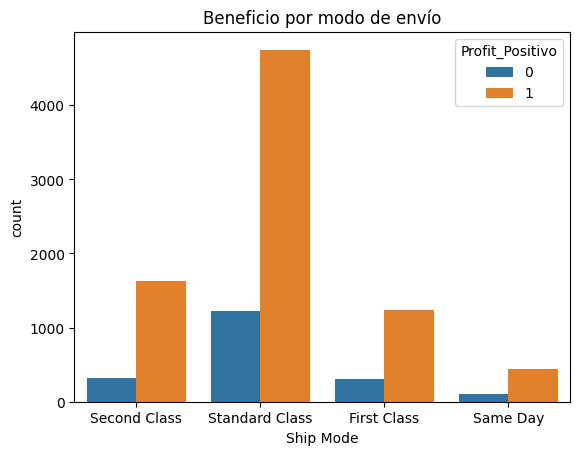

In [88]:
sns.countplot(x='Ship Mode', hue='Profit_Positivo', data=df)
plt.title('Beneficio por modo de envío')
plt.show()

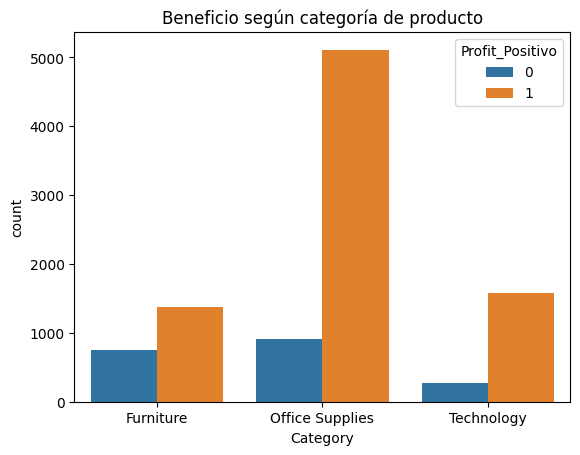

In [89]:
sns.countplot(x='Category', hue='Profit_Positivo', data=df)
plt.title('Beneficio según categoría de producto')
plt.show()

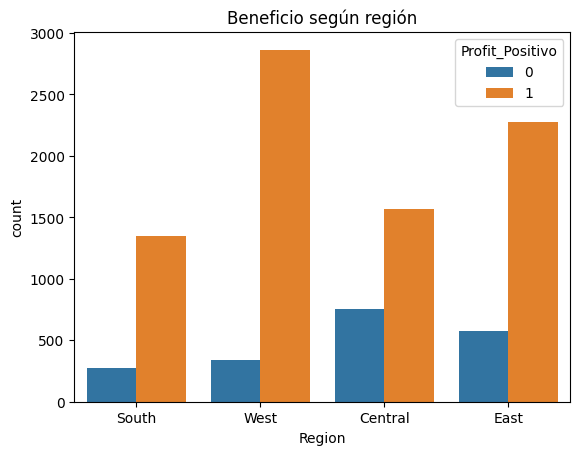

In [90]:
sns.countplot(x='Region', hue='Profit_Positivo', data=df)
plt.title('Beneficio según región')
plt.show()

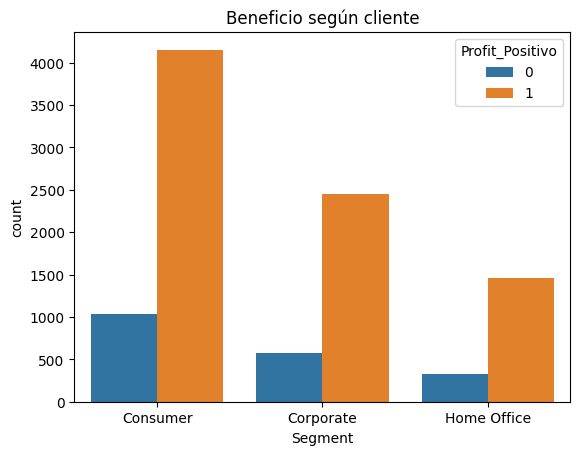

In [91]:
sns.countplot(x='Segment', hue='Profit_Positivo', data=df)
plt.title('Beneficio según cliente')
plt.show()

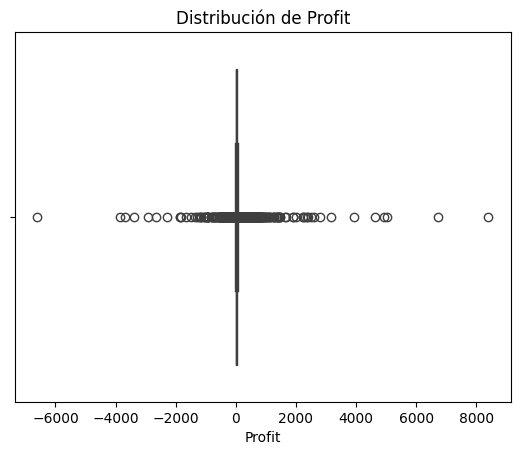

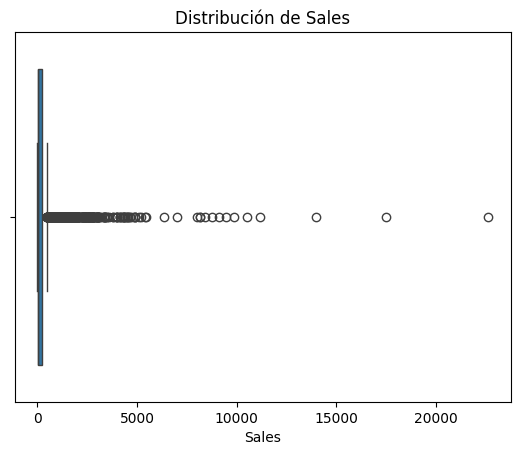

In [92]:
for col in ['Profit', 'Sales']:
    sns.boxplot(x=df[col])
    plt.title(f'Distribución de {col}')
    plt.show()

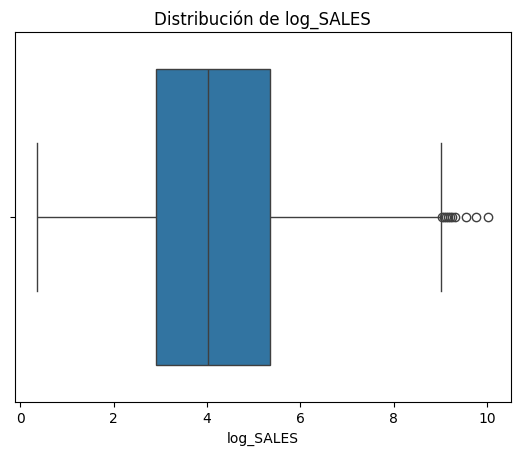

In [93]:
for col in ['log_SALES']:
    sns.boxplot(x=df[col])
    plt.title(f'Distribución de {col}')
    plt.show()

In [94]:
#Reducimos el número de outliers si bien siguen quedando algunos.

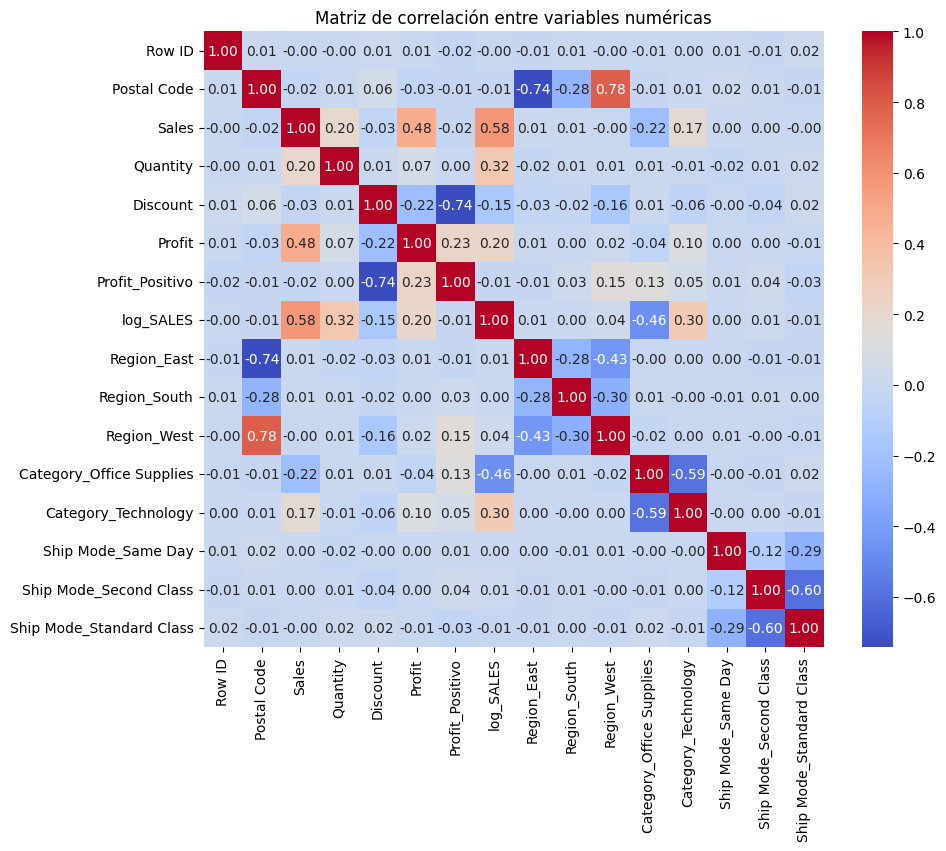

In [95]:
corr = df_encoded.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación entre variables numéricas')
plt.show()

In [96]:
# 5. Hot - Encoding para las variables categóricas Region y Category.
import pandas as pd

df = pd.get_dummies(
    df,
    columns=["Region", "Category", "Ship Mode"],
    drop_first=True,
    dtype=int
)

print(df.head())

   Row ID        Order ID  Order Date   Ship Date Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   ...  Profit_Positivo log_SALES Region_East Region_South  Region_West  \
0  ...                1  5.572002           0            1            0

In [97]:
#Con las cuatro primeras gráficas,
#no se apreciaba una relación clara entre un beneficio negativo/positivo.
#Sin embargo, con la matriz de correlación,
#vemos que hay una correlación inversa entre el descuento y el beneficio.
#A mayor descuento, el beneficio tiende a ser negativo.

In [98]:
bins = [-1, 0.3, 0.7, 1]
labels = ['low', 'mid', 'high']

df_encoded['Discount_Level'] = pd.cut(
    df['Discount'],
    bins=bins,
    labels=labels
)

print(df_encoded[['Discount']].assign(Discount_Level=df_encoded['Discount_Level']).head(20))


    Discount Discount_Level
0       0.00            low
1       0.00            low
2       0.00            low
3       0.45            mid
4       0.20            low
5       0.00            low
6       0.00            low
7       0.20            low
8       0.20            low
9       0.00            low
10      0.20            low
11      0.20            low
12      0.20            low
13      0.20            low
14      0.80           high
15      0.80           high
16      0.00            low
17      0.00            low
18      0.00            low
19      0.20            low


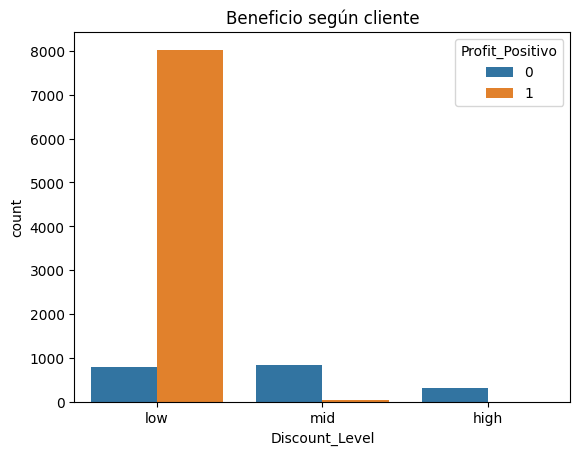

In [126]:
sns.countplot(x='Discount_Level', hue='Profit_Positivo', data=df_encoded)
plt.title('Beneficio según cliente')
plt.show()

In [100]:
# 7. Explicaciones y decisiones en función de los resultados.
#Una vez graficados los resultados, vemos una relación inversa entre el descuento y el beneficio.
#A mayor descuento, el beneficio es negativoy viciversa.
#Vamos a continuar estudiando esta relación, ya que el objetivo de este análisis es predecir el posible beneficio.

## Fase 1.2: Clasificación

1. Selección del target categórico
2. Entrenamiento de un primer modelo + cálculo de métricas
3. Gráficas clave (matriz de confusión y curva ROC comparativa)
4. Entrenamiento de un segundo modelo + cálculo de métricas
5. Gráficas clave segundo modelo (matriz de confusión y curva ROC comparativa)
6. Comparativa de métricas
7. Explicación: cuál eliges y por qué


In [101]:
# 1. Selección del target categórico

In [127]:
target = "Profit_Positivo"

X = df.drop(columns=[target, "Profit", "Sales"])  # quitamos Profit para evitar fuga de información y Sales para evitar generar multicolinealidad con log_Sales
y = df[target]
X = pd.get_dummies(X, drop_first=True)

In [128]:
# División train y test

In [129]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# 2. Primer modelo: Logic Regresion

In [134]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model1 = LogisticRegression(max_iter=2000)

model1.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [135]:
y_pred1 = model1.predict(X_test)
y_prob1 = model1.predict_proba(X_test)[:,1]

In [136]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Logistic Regression")

print("Accuracy:", accuracy_score(y_test, y_pred1))
print("Precision:", precision_score(y_test, y_pred1))
print("Recall:", recall_score(y_test, y_pred1))
print("F1:", f1_score(y_test, y_pred1))

Logistic Regression
Accuracy: 0.9219609804902451
Precision: 0.9510532837670385
Recall: 0.9522332506203474
F1: 0.9516429014259145


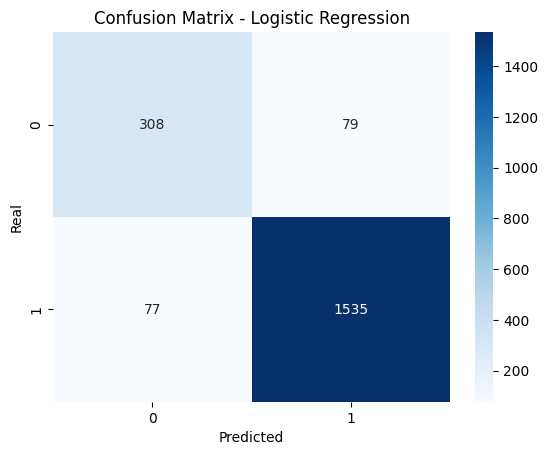

In [137]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm1 = confusion_matrix(y_test, y_pred1)

sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Real")

plt.show()

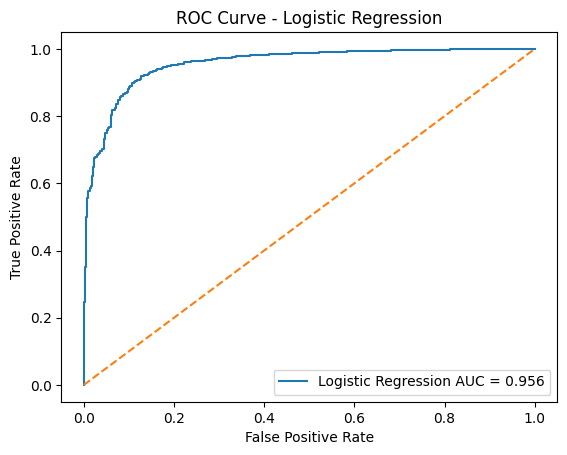

In [138]:
from sklearn.metrics import roc_curve, auc

fpr1, tpr1, _ = roc_curve(y_test, y_prob1)
roc_auc1 = auc(fpr1, tpr1)

plt.plot(fpr1, tpr1, label=f"Logistic Regression AUC = {roc_auc1:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

In [ ]:
# Segundo modelo: KNN

In [139]:
from sklearn.neighbors import KNeighborsClassifier

model2 = KNeighborsClassifier(n_neighbors=5)

model2.fit(X_train, y_train)

KNeighborsClassifier()

In [140]:
y_pred2 = model2.predict(X_test)
y_prob2 = model2.predict_proba(X_test)[:,1]

In [141]:
print("KNN")

print("Accuracy:", accuracy_score(y_test, y_pred2))
print("Precision:", precision_score(y_test, y_pred2))
print("Recall:", recall_score(y_test, y_pred2))
print("F1:", f1_score(y_test, y_pred2))

KNN
Accuracy: 0.8139069534767384
Precision: 0.8329752953813104
Recall: 0.9621588089330024
F1: 0.8929188255613126


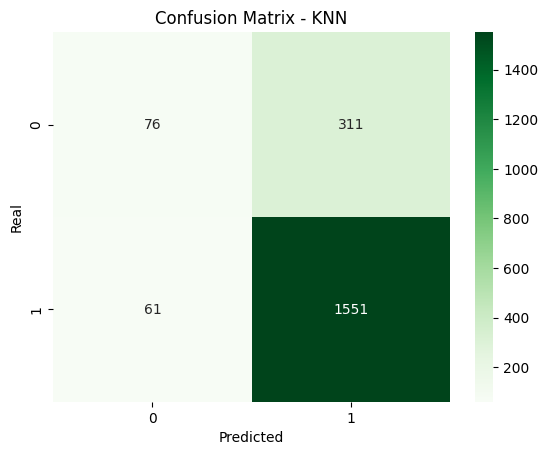

In [142]:
cm2 = confusion_matrix(y_test, y_pred2)

sns.heatmap(cm2, annot=True, fmt="d", cmap="Greens")

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Real")

plt.show()

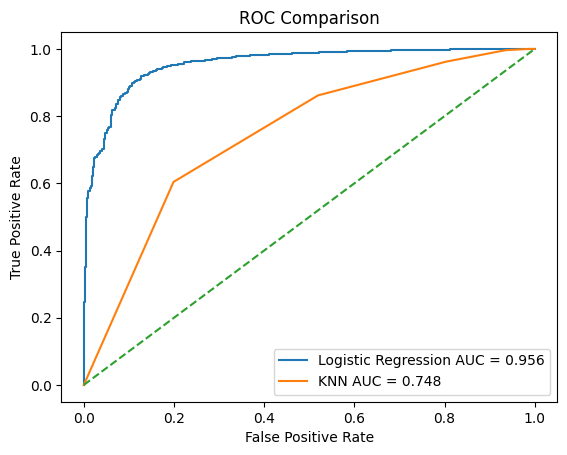

In [143]:
fpr2, tpr2, _ = roc_curve(y_test, y_prob2)
roc_auc2 = auc(fpr2, tpr2)

plt.plot(fpr1, tpr1, label=f"Logistic Regression AUC = {roc_auc1:.3f}")
plt.plot(fpr2, tpr2, label=f"KNN AUC = {roc_auc2:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Comparison")

plt.legend()

plt.show()

In [144]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN"],
    "Accuracy":[
        accuracy_score(y_test, y_pred1),
        accuracy_score(y_test, y_pred2)
    ],
    "Precision":[
        precision_score(y_test, y_pred1),
        precision_score(y_test, y_pred2)
    ],
    "Recall":[
        recall_score(y_test, y_pred1),
        recall_score(y_test, y_pred2)
    ],
    "F1":[
        f1_score(y_test, y_pred1),
        f1_score(y_test, y_pred2)
    ],
    "ROC_AUC":[roc_auc1, roc_auc2]
})

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.921961,0.951053,0.952233,0.951643,0.955758
1,KNN,0.813907,0.832975,0.962159,0.892919,0.747701


## Fase 1.3: Regresión

1. Selección del target numérico
2. Entrenamiento de un primer modelo + cálculo de métricas
3. Gráficas clave (visualización de predicciones)
4. Entrenamiento de un segundo modelo + cálculo de métricas
5. Gráficas clave segundo modelo (visualización de predicciones)
6. Comparativa de métricas
7. Explicación: cuál eliges y por qué

In [102]:
# Selección del target numérico

In [145]:
target = "Profit"

X = df.drop(columns=[target])  # quitamos Profit para no filtrarlo
y = df[target]

# Convertimos categóricas a dummies
X = pd.get_dummies(X, drop_first=True)

In [146]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Primer modelo: Regresión Lineal

In [154]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Modelo entrenado.')

Modelo entrenado.


In [155]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Linear Regression")
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print('MSE:', mse)
print('RMSE:', rmse)
print('R2:', r2)

Linear Regression
MSE: 1711732.190925797
RMSE: 1308.331835172483
R2: -34.30427453727305


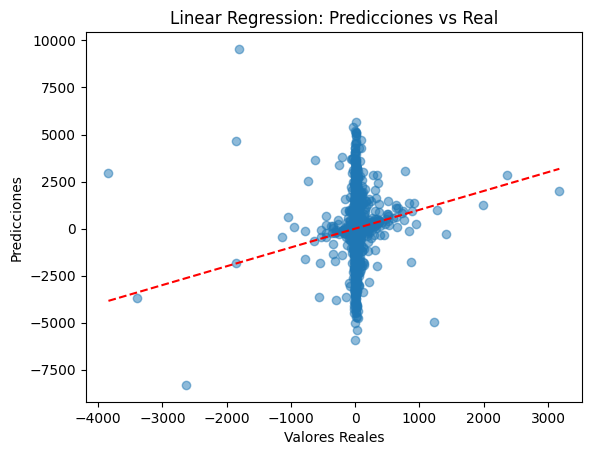

In [156]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred1, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Linear Regression: Predicciones vs Real")
plt.show()

In [ ]:
# Segundo modelo:

## Fase 1.4: PCA y No Supervisados

1. Aplicación de PCA
2. Visualización de la reducción de dimensiones
3. Interpretación de los componentes principales
4. Selección de un modelo no supervisado (KMeans, DBSCAN o LOF)
5. Entrenamiento del modelo seleccionado
6. Visualización de resultados (clusters o anomalías)
7. Cálculo de métricas si aplica
8. Interpretación de resultados desde un punto de vista de negocio

Explicación: qué patrones se han descubierto y qué implicaciones tendría para negocio

In [103]:
# Desarrolla tu código de PCA y No Supervisados

----

## 🔒 FASE 2 — Se desbloquea en Semana 2 (solo entonces editar esta parte)


## Contexto y objetivo

Una vez llegados aquí, podríamos seguir el ejercicio por dos vias.


**Vía 1:**  
Clasificación: Cliente rentable vs no rentable ( Profit > 0 )

**Vía 2:**  
Regresión: Predicción del profit

**Vía 3::**  
Calcular ambos tipos de modelos.


Para no hacer el ejercicio muy largo optaremos por la vía 2, predicción del profit, dejamos como opcional la vía 1.

# Fase 2 - Elección razonada del modelo

Antes de entrenar cualquier modelo, un buen científico de datos **justifica su elección**. Esta reflexión es clave en proyectos reales: los stakeholders querrán saber por qué usamos un algoritmo concreto.

### ¿Por qué modelos basados en árboles para predecir el Profit?

| Criterio | Situación en nuestro dataset | Ventaja de los árboles |
|----------|------------------------------|------------------------|
| **Relaciones no lineales** | Descuento alto → Profit negativo de forma no lineal | Los árboles capturan estas curvas sin transformaciones |
| **Interacciones entre variables** | Categoría + Descuento → Profit muy diferente | Los árboles modelan interacciones automáticamente |
| **Variables mixtas** | Numéricas (Sales) y categóricas codificadas | No requieren escalado ni normalización |
| **Outliers en el target** | Profit tiene valores extremos (pérdidas y ganancias grandes) | Más robustos que la regresión lineal |
| **Interpretabilidad** | El negocio quiere entender qué impulsa el beneficio | Feature importance + SHAP |

In [104]:
# Qué modelo creeis que funcionará mejor con estos datos y porqué.
# ---

**✍️ Si no tienes claro que modelo es el mejor, saltate este apartado y completalo al final de la sesión.:**

*(Vamos a hacer una propuesta interesante, vamos a probar diferentes modelos para decirdir con criterio)*

---
## Fase 2.1 - Decision Tree: El Baseline

Empezamos con el modelo más sencillo. Un árbol de decisión individual nos servirá como **línea base** (baseline): cualquier modelo más complejo deberá superarlo.

💡 **Analogía de negocio:** El árbol de decisión es como el proceso de aprobación manual de un crédito: el gestor sigue un formulario de preguntas fijas. Funciona, pero es rígido y fácil de engañar.

In [105]:
#Pistas, recuerda tener cargadas todas las librerias
#!pip install xgboost shap --quiet

#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
#import matplotlib.ticker as mtick
#import seaborn as sns
#import warnings
#warnings.filterwarnings('ignore')

#from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
#from sklearn.preprocessing import LabelEncoder
#from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
#from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
#from sklearn.ensemble import RandomForestRegressor

#from xgboost import XGBRegressor

#import shap
#shap.initjs()

In [106]:
# -------------------------------------------------------
# ENTRENAMIENTO — Decision Tree Regressor
# -------------------------------------------------------


#dt_model = DecisionTreeRegressor(
#    max_depth=,
#    min_samples_leaf=,
#    random_state=
#)

#dt_model.fit(X_train, y_train)

#dt_preds = dt_model.predict(X_test)

**✍️ Conclusiones sobre este modelo.

In [107]:
#

---
## Fase 2.2 - Random Forest: Bagging

💡 **Analogía de negocio:** Es como pedir opinión a 200 asesores financieros independientes y hacer la media. Ninguno es perfecto, pero juntos son mucho más fiables que uno solo.

In [108]:
# -------------------------------------------------------
# ENTRENAMIENTO — Random Forest Regressor
# -------------------------------------------------------

#rf_model = RandomForestRegressor(
#    n_estimators=...,
#    max_depth=....,
#    max_features=...,
#    n_jobs=....,
#    random_state=....
#)

#rf_model.fit(X_train, y_train)

#rf_preds = rf_model.predict(X_test)

**✍️ Conclusiones sobre este modelo.

In [109]:
#

---
## Fase 2.3 - XGBoost: Boosting

💡 **Analogía de negocio:** En lugar de promediar opiniones (Random Forest), el equipo hace una **revisión por rondas**: en cada ronda analiza los casos donde se equivocó antes y manda al mejor especialista para corregirlos.

In [110]:
# -------------------------------------------------------
# ENTRENAMIENTO — XGBoost Regressor
# -------------------------------------------------------


#xgb_model = XGBRegressor(
#    n_estimators=....,
#    max_depth=...,
#    learning_rate=...,
#    subsample=....,
#    colsample_bytree=...,
#    reg_alpha=....,
#    reg_lambda=...,
#    random_state=...,
#    verbosity=....
#)

#xgb_model.fit(X_train, y_train)

#xgb_preds = xgb_model.predict(X_test)

**✍️ Conclusiones sobre este modelo.

In [111]:
#

---
## Fase 2.4 — Fine-tuning con GridSearchCV

💡 **Analogía de negocio:** Es como testear sistemáticamente distintas configuraciones de una campaña de marketing (audiencia × presupuesto × creatividad) y quedarte con la combinación que maximiza el ROI.

In [112]:
# -------------------------------------------------------
# FINE-TUNING — GridSearchCV sobre XGBoost (Ejemplo sobre XGBoost, si has elegido otro, hazlo sobre tu elección)
# -------------------------------------------------------


#param_grid = {
#    'n_estimators'    : [200, 400],
#    'max_depth'       : [4, 6],
#    'learning_rate'   : [0.05, 0.1],
#    'subsample'       : [0.7, 0.9],
#    'colsample_bytree': [0.7, 1.0],
#}

#xgb_base = XGBRegressor(random_state=42, verbosity=0)

#grid_search = GridSearchCV(
#    estimator=xgb_base,
#    param_grid=param_grid,
#    scoring='neg_root_mean_squared_error',
#    cv=....,
#    n_jobs=.....,
#    verbose=....
#)

#grid_search.fit(X_train, y_train)

---
## Fase 2.5 — Explicabilidad con SHAP

💡 **Analogía:** SHAP es como el desglose de una factura. No te dice solo el total (la predicción), sino cuánto contribuye cada concepto (feature) al precio final.

| Gráfico SHAP | ¿Qué muestra? | ¿Para quién? |
|---|---|---|
| Summary plot | Impacto global de cada variable | Presentación a dirección |
| Waterfall | Explicación de una predicción individual | Análisis de un pedido concreto |
| Dependence plot | Relación variable↔SHAP | Equipos de negocio y pricing |

In [113]:
# -------------------------------------------------------
# SHAP PLOT 1 — Summary Plot (visión global)
# -------------------------------------------------------

In [114]:
# -------------------------------------------------------
# SHAP PLOT 2 — Waterfall: explicamos UN pedido concreto
# -------------------------------------------------------

In [115]:
# -------------------------------------------------------
# SHAP PLOT 3 — Dependence Plot: efecto del Discount
# -------------------------------------------------------

**✍️ Reflexión SHAP (SOLUCIÓN):**

1. **Top 3 variables según SHAP:** .... Rellenar...

---
## Fase 2.5 — Conclusión y Recomendaciones de Negocio

In [116]:
#Comenta que conclusiones has sacado despues de ejecutar los modelos y que recomendaciones de negocio harias.